# 34 — Canonical InceptionTime and MiniROCKET corrective benchmark

This is the single corrective benchmark authorized by notebook 33. It compares the unchanged notebook-29 lower-back incumbent with canonical-mechanics InceptionTime, canonical 10,000-feature MiniROCKET, and three fixed equal-probability fusions.

## Locked evidence contract

- Input remains one 500-sample lower-back acceleration-magnitude channel.
- Development sources are Felius, Voisard, and Sint. Each complete source is held out in turn.
- Five fixed seeds are evaluated and all metrics are aggregated at participant level.
- Normalization, MiniROCKET bias fitting, Ridge fitting, and probability calibration use training sources only.
- RevalExo and NONAN are not loaded and cannot select any model, threshold, or fusion.
- A replacement must reduce both mean FP and mean FN, reduce total errors by at least 10%, have paired-bootstrap support, avoid mean error regression in every held-out source, and preserve discrimination and calibration.
- If no candidate passes every condition, model rotation stops and the notebook-29 incumbent remains selected.


In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.canonical_corrective_benchmark import CorrectiveConfig, run

assert torch.cuda.is_available(), 'CUDA is required for canonical InceptionTime'
module_path = ROOT / 'src' / 'models' / 'canonical_corrective_benchmark.py'
module_text = module_path.read_text(encoding='utf-8').lower()
for forbidden in ('revalexo_external_windows', 'nonan_external_windows'):
    assert forbidden not in module_text, f'Frozen-cohort loader reference found: {forbidden}'
config = CorrectiveConfig()
print('Project:', ROOT)
print('GPU:', torch.cuda.get_device_name(0))
print('Seeds:', config.seeds)
print('Frozen selection cohorts loaded: NONE')


Project: C:\Users\frank\Documents\MR-ICT Review Paper
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Seeds: (42, 137, 202, 314, 515)
Frozen selection cohorts loaded: NONE


In [2]:
result = run(ROOT, config)


GPU candidate: NVIDIA GeForce RTX 5060 Laptop GPU
MiniROCKET CPU workers: 16
source                y
felius_2024           0     34
                      1    129
sint_maartenskliniek  0     20
                      1     10
voisard_2025          0     72
                      1     49
Name: participants, dtype: int64


C:\Users\frank\Documents\MR-ICT Review Paper\src\models\canonical_corrective_benchmark.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  frame = frame.loc[frame.get("validation", False).fillna(False)].copy()


InceptionTime tuned: held_out=felius_2024 epochs=8


C:\Users\frank\Documents\MR-ICT Review Paper\src\models\canonical_corrective_benchmark.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  frame = frame.loc[frame.get("validation", False).fillna(False)].copy()


InceptionTime tuned: held_out=sint_maartenskliniek epochs=24


...

MiniROCKET complete: held_out=voisard_2025 seed=137 alpha=215.443 BA=0.838 FP=16 FN=5


MiniROCKET complete: held_out=voisard_2025 seed=202 alpha=215.443 BA=0.838 FP=13 FN=7


MiniROCKET complete: held_out=voisard_2025 seed=314 alpha=215.443 BA=0.800 FP=17 FN=8


MiniROCKET complete: held_out=voisard_2025 seed=515 alpha=215.443 BA=0.821 FP=17 FN=6



OVERALL PARTICIPANT-LEVEL RESULTS
                        method  auroc  brier  balanced_accuracy  specificity  sensitivity  false_positives  false_negatives  total_errors
       canonical_inceptiontime 0.8273 0.2360             0.7418       0.6939       0.7897          13.0667          19.0667       32.1333
          canonical_minirocket 0.8572 0.1582             0.8029       0.7710       0.8348           9.4000          13.8667       23.2667
              fusion_all_three 0.8860 0.1599             0.7954       0.7471       0.8437          10.2000          14.6667       24.8667
fusion_incumbent_inceptiontime 0.8857 0.1713             0.7834       0.7479       0.8190          10.4667          15.7333       26.2000
   fusion_incumbent_minirocket 0.8869 0.1427             0.8145       0.7733       0.8557           9.3333          12.8000       22.1333
          incumbent_notebook29 0.8882 0.1425             0.8140       0.7743       0.8537           9.8000          11.9333       21.7333

In [3]:
display(result['overall'].sort_values(['total_errors', 'balanced_accuracy'], ascending=[True, False]).round(4))
display(result['summary'].sort_values(['method', 'held_out_source']).round(4))
display(result['source_deltas'].sort_values(['method', 'held_out_source']).round(4))


,method,auroc,brier,balanced_accuracy,specificity,sensitivity,false_positives,false_negatives,total_errors
5,incumbent_notebook29,0.8882,0.1425,0.8140,0.7743,0.8537,9.8000,11.9333,21.7333
4,fusion_incumbent_minirocket,0.8869,0.1427,0.8145,0.7733,0.8557,9.3333,12.8000,22.1333
1,canonical_minirocket,0.8572,0.1582,0.8029,0.7710,0.8348,9.4000,13.8667,23.2667
2,fusion_all_three,0.8860,0.1599,0.7954,0.7471,0.8437,10.2000,14.6667,24.8667
3,fusion_incumbent_inceptiontime,0.8857,0.1713,0.7834,0.7479,0.8190,10.4667,15.7333,26.2000
0,canonical_inceptiontime,0.8273,0.2360,0.7418,0.6939,0.7897,13.0667,19.0667,32.1333


,method,held_out_source,auroc,brier,balanced_accuracy,specificity,sensitivity,false_positives,false_negatives
0,canonical_inceptiontime,felius_2024,0.8291,0.2546,0.7280,0.8529,0.6031,5.0,51.2
1,canonical_inceptiontime,sint_maartenskliniek,0.7910,0.2533,0.7250,0.5900,0.8600,8.2,1.4
2,canonical_inceptiontime,voisard_2025,0.8616,0.2002,0.7725,0.6389,0.9061,26.0,4.6
3,canonical_minirocket,felius_2024,0.8377,0.1834,0.7586,0.7824,0.7349,7.4,34.2
4,canonical_minirocket,sint_maartenskliniek,0.8410,0.1541,0.8250,0.7500,0.9000,5.0,1.0
5,canonical_minirocket,voisard_2025,0.8931,0.1371,0.8250,0.7806,0.8694,15.8,6.4
6,fusion_all_three,felius_2024,0.8597,0.1861,0.7471,0.8059,0.6884,6.6,40.2
7,fusion_all_three,sint_maartenskliniek,0.8670,0.1649,0.7900,0.6800,0.9000,6.4,1.0
8,fusion_all_three,voisard_2025,0.9311,0.1289,0.8492,0.7556,0.9429,17.6,2.8
9,fusion_incumbent_inceptiontime,felius_2024,0.8626,0.1937,0.7460,0.8176,0.6744,6.2,42.0


,method,held_out_source,total_error_delta,balanced_accuracy_delta,specificity_delta,sensitivity_delta,auroc_delta
0,canonical_inceptiontime,felius_2024,17.6,-0.0357,0.0882,-0.1597,-0.0297
1,canonical_inceptiontime,sint_maartenskliniek,4.4,-0.1150,-0.2100,-0.0200,-0.1040
2,canonical_inceptiontime,voisard_2025,9.2,-0.0658,-0.1194,-0.0122,-0.0492
3,canonical_minirocket,felius_2024,3.0,-0.0051,0.0176,-0.0279,-0.0212
4,canonical_minirocket,sint_maartenskliniek,0.8,-0.0150,-0.0500,0.0200,-0.0540
5,canonical_minirocket,voisard_2025,0.8,-0.0134,0.0222,-0.0490,-0.0177
6,fusion_all_three,felius_2024,8.2,-0.0166,0.0412,-0.0744,0.0009
7,fusion_all_three,sint_maartenskliniek,2.2,-0.0500,-0.1200,0.0200,-0.0280
8,fusion_all_three,voisard_2025,-1.0,0.0109,-0.0028,0.0245,0.0203
9,fusion_incumbent_inceptiontime,felius_2024,9.6,-0.0177,0.0529,-0.0884,0.0038


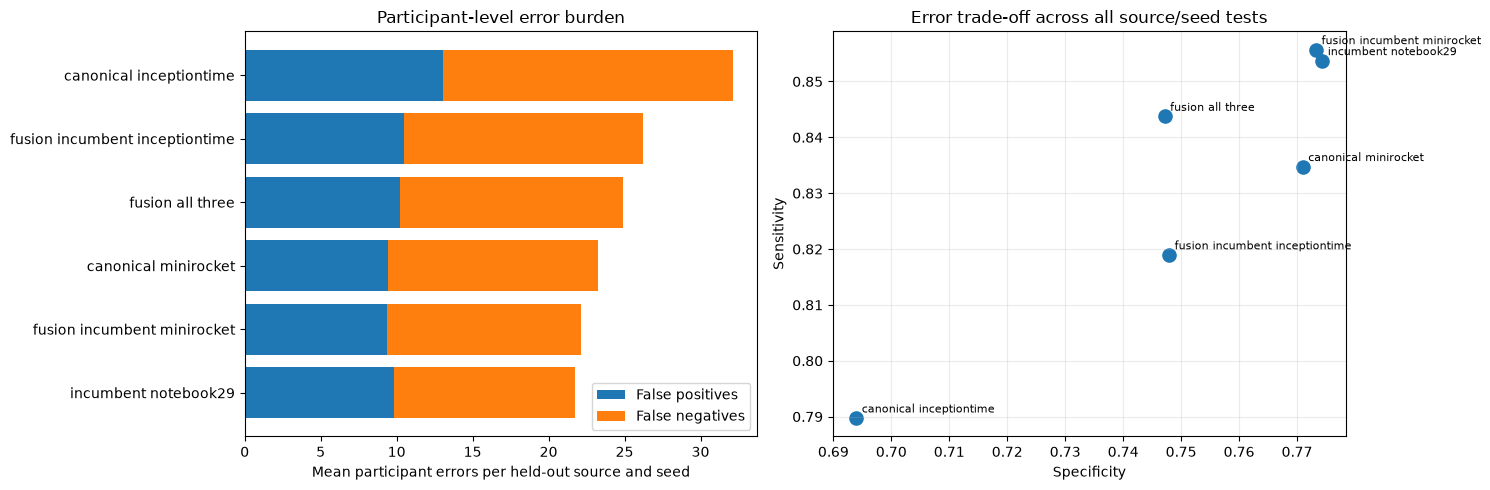

In [4]:
plot = result['overall'].copy().sort_values('total_errors')
labels = plot['method'].str.replace('_', ' ', regex=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(labels, plot['false_positives'], label='False positives')
axes[0].barh(labels, plot['false_negatives'], left=plot['false_positives'], label='False negatives')
axes[0].set_xlabel('Mean participant errors per held-out source and seed')
axes[0].set_title('Participant-level error burden')
axes[0].legend()
axes[1].scatter(plot['specificity'], plot['sensitivity'], s=90)
for _, row in plot.iterrows():
    axes[1].annotate(row['method'].replace('_', ' '), (row['specificity'], row['sensitivity']), fontsize=8, xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('Specificity')
axes[1].set_ylabel('Sensitivity')
axes[1].set_title('Error trade-off across all source/seed tests')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
decision = result['decision']
print('FINAL CORRECTIVE-BENCHMARK DECISION')
print('Improvement found:', decision['improvement_found'])
print('Selected method:', decision['selected_method'])
if decision['improvement_found']:
    print('A candidate passed every predeclared participant- and source-level gate. Stop architecture search and freeze it for untouched external evaluation.')
else:
    print('No candidate passed every gate. Retain notebook-29 and stop model rotation; the remaining limitation is representative paired external data.')
print(json.dumps(decision['candidate_decisions'], indent=2))


FINAL CORRECTIVE-BENCHMARK DECISION
Improvement found: False
Selected method: incumbent_notebook29
No candidate passed every gate. Retain notebook-29 and stop model rotation; the remaining limitation is representative paired external data.
{
  "canonical_inceptiontime": {
    "accepted": false,
    "both_fp_and_fn_improved": false,
    "every_source_nonregressing": false,
    "discrimination_and_calibration_safe": false,
    "material_total_error_reduction": false,
    "total_error_ci_supports_nonincrease": false,
    "mean_total_errors_baseline": 21.733333333333334,
    "mean_total_errors_candidate": 32.13333333333333,
    "relative_total_error_reduction": -0.4785276073619631,
    "paired_bootstrap": {
      "balanced_accuracy": {
        "mean_delta": -0.07219066179443354,
        "ci_low": -0.11172407335027038,
        "ci_high": -0.03882894824596508
      },
      "specificity": {
        "mean_delta": -0.08040305010893248,
        "ci_low": -0.18920561002178646,
        "ci_high":